# QUI EMPRUNTE QUOI ?

## Feuille de route
* Gros emprunteurs ou petits emprunteurs ?
* Emprunteurs réguliers ou emprunteurs ponctuels ?
* Quel usage des collections par âge ? (les + et les - empruntées, filtre 10 ccodes)

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import datetime

from kiblib.utils.db import DbConn
from kiblib.utils import lucas_sns_params

In [52]:
query = "SELECT * FROM statdb.stat_issues WHERE YEAR(issuedate)='2025'"

In [53]:
db_conn = DbConn().create_engine()
issues = pd.read_sql(query,con=db_conn)

In [54]:
issues['année'] = pd.DatetimeIndex(issues['issuedate']).year

In [55]:
issues['nb'] = 1

In [56]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,itemtype,publicationyear,biblionumber,dateaccessioned,cle,timestamp,issue_id,returnbranch,année,nb
0,2025-01-02 08:51:15,2025-02-22 23:59:00,NaT,0,MED,None,668,X61,64,M,...,VD,2024,370947.0,2024-12-07,2025-01-02 08:51:15-487483,2025-01-04 03:11:11,5190414,None,2025,1
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,VD,2024,368381.0,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,2025,1
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,LI,2020,332180.0,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,2025,1
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,VD,2024,369018.0,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,2025,1
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,LI,2009,278063.0,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,2025,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260032,2025-10-02 10:46:23,2025-10-23 23:59:00,2025-10-02 11:02:24,0,MED,None,21674,X0002606088,58,M,...,None,2025,374250.0,2025-05-13,None,2025-10-03 03:13:01,5556939,None,2025,1
260033,2025-10-02 12:05:32,2025-10-23 23:59:00,2025-10-02 12:17:51,0,MED,None,6509,X0002462165,76,F,...,LI,2020,332210.0,2020-12-04,None,2025-10-03 03:13:01,5556940,None,2025,1
260034,2025-10-02 16:17:13,2025-10-23 23:59:00,2025-10-02 16:30:35,0,MED,None,44856,X0002201351,61,F,...,DC,2021,339063.0,2021-07-21,None,2025-10-03 03:13:01,5556941,None,2025,1
260035,2025-10-02 17:20:14,2025-10-23 23:59:00,2025-10-02 17:31:17,0,MED,None,79684,X0002831770,9,F,...,LI,2016,295338.0,2017-02-15,None,2025-10-03 03:13:01,5556942,None,2025,1


In [57]:
# 2 méthodes pour faire la même chose

#Avec transform
issues['nb docs empruntés pour cet emprunteur'] = issues.groupby('borrowernumber')['borrowernumber'].transform('count')


# Avec map + valuecounts()
issues['nb docs empruntés pour cet emprunteur 2'] = issues['borrowernumber'].map(issues['borrowernumber'].value_counts())

In [58]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,biblionumber,dateaccessioned,cle,timestamp,issue_id,returnbranch,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2
0,2025-01-02 08:51:15,2025-02-22 23:59:00,NaT,0,MED,None,668,X61,64,M,...,370947.0,2024-12-07,2025-01-02 08:51:15-487483,2025-01-04 03:11:11,5190414,None,2025,1,39,39
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,368381.0,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,2025,1,39,39
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,332180.0,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,2025,1,169,169
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,369018.0,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,2025,1,123,123
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,278063.0,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,2025,1,45,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260032,2025-10-02 10:46:23,2025-10-23 23:59:00,2025-10-02 11:02:24,0,MED,None,21674,X0002606088,58,M,...,374250.0,2025-05-13,None,2025-10-03 03:13:01,5556939,None,2025,1,70,70
260033,2025-10-02 12:05:32,2025-10-23 23:59:00,2025-10-02 12:17:51,0,MED,None,6509,X0002462165,76,F,...,332210.0,2020-12-04,None,2025-10-03 03:13:01,5556940,None,2025,1,71,71
260034,2025-10-02 16:17:13,2025-10-23 23:59:00,2025-10-02 16:30:35,0,MED,None,44856,X0002201351,61,F,...,339063.0,2021-07-21,None,2025-10-03 03:13:01,5556941,None,2025,1,188,188
260035,2025-10-02 17:20:14,2025-10-23 23:59:00,2025-10-02 17:31:17,0,MED,None,79684,X0002831770,9,F,...,295338.0,2017-02-15,None,2025-10-03 03:13:01,5556942,None,2025,1,400,400


In [59]:
issues['nb personnes ayant emprunté ce nombre de livre en 2025'] = issues['nb docs empruntés pour cet emprunteur'].map(issues['nb docs empruntés pour cet emprunteur'].value_counts())

In [60]:
issues_dist = issues.drop_duplicates(subset=['borrowernumber'],keep='first')

In [61]:
issues_dist

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,dateaccessioned,cle,timestamp,issue_id,returnbranch,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2,nb personnes ayant emprunté ce nombre de livre en 2025
0,2025-01-02 08:51:15,2025-02-22 23:59:00,NaT,0,MED,None,668,X61,64,M,...,2024-12-07,2025-01-02 08:51:15-487483,2025-01-04 03:11:11,5190414,None,2025,1,39,39,2496
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,2025,1,169,169,169
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,2025,1,123,123,984
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,2025,1,45,45,2025
6,2025-01-02 09:45:47,2025-01-23 23:59:00,2025-01-09 15:36:31,0,MED,None,9572,X0002555904,76,M,...,2018-11-02,2025-01-02 09:45:47-383954,2025-01-10 03:13:54,5190420,None,2025,1,10,10,4060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259897,2025-10-02 15:04:20,2025-10-23 23:59:00,NaT,0,MED,None,87652,X0002683034,5,M,...,2022-07-02,None,2025-10-03 03:13:01,5556787,None,2025,1,1,1,813
259914,2025-10-02 15:22:03,2025-10-23 23:59:00,NaT,0,MED,None,77980,X0002698595,5,F,...,2025-05-28,None,2025-10-03 03:13:01,5556804,None,2025,1,1,1,813
259945,2025-10-02 16:06:31,2025-10-23 23:59:00,NaT,0,MED,None,87654,X0002849423,9,F,...,2021-04-01,None,2025-10-03 03:13:01,5556835,None,2025,1,5,5,2055
259993,2025-10-02 17:02:26,2025-10-23 23:59:00,NaT,0,MED,None,87018,X0002784571,20,F,...,2013-05-02,None,2025-10-03 03:13:01,5556883,None,2025,1,1,1,813


In [62]:
issues_dist = issues_dist.groupby('nb docs empruntés pour cet emprunteur')['nb personnes ayant emprunté ce nombre de livre en 2025'].size().to_frame().reset_index()

In [63]:
issues_dist['volume docs empruntés'] = issues_dist['nb docs empruntés pour cet emprunteur'] * issues_dist['nb personnes ayant emprunté ce nombre de livre en 2025']

In [95]:
issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=1)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=10),
                'nb docs empruntés label'
               ] = 'a/ Entre 1 et 10 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=11)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=20),
                'nb docs empruntés label',
               ] = 'b/ Entre 11 et 20 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=21)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=40),
                'nb docs empruntés label',
               ] = 'c/ Entre 21 et 40 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=41)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=60),
                'nb docs empruntés label',
               ] = 'd/ Entre 41 et 60 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=61)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=80),
                'nb docs empruntés label',
               ] = 'e/ Entre 61 et 80 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=81)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=100),
                'nb docs empruntés label',
               ] = 'f/ Entre 81 et 100 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=101)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=120),
                'nb docs empruntés label',
               ] = 'g/ Entre 101 et 120 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=121)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=140),
                'nb docs empruntés label',
               ] = 'h/ Entre 121 et 140 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=141)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=160),
                'nb docs empruntés label',
               ] = 'i/ Entre 141 et 160 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=161)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=180),
                'nb docs empruntés label',
               ] = 'j/ Entre 161 et 180 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=181)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=200),
                'nb docs empruntés label',
               ] = 'k/ Entre 181 et 200 \ndocs empruntés'


issues_dist.loc[issues_dist['nb docs empruntés pour cet emprunteur']>=200,
                'nb docs empruntés label',
               ] = 'x/ Plus de 200 \ndocs empruntés'

In [155]:
# Comment automatiser la création des labels au-dessus ↑
nmin = 1
nmax=10
for i in range(1,21):
    print(f"tour n°{i}")
    print("° "*10)
    print(f"x/ Entre {nmin} et {nmax} docs empruntés sur la période")
    print(" ")
    
    # Ajout d'un label "test" contenant l'interval de docs empruntés
    
    issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=nmin)&
                    (issues_dist['nb docs empruntés pour cet emprunteur']<=nmax),
                    'test label boucle période'
                   ] = f'{i}/ Entre {nmin} et {nmax} docs empruntés sur la période'
    
    nmin+= 10
    nmax+= 10
    chapter+=1
    

tour n°1
° ° ° ° ° ° ° ° ° ° 
x/ Entre 1 et 10 docs empruntés sur la période
 
tour n°2
° ° ° ° ° ° ° ° ° ° 
x/ Entre 11 et 20 docs empruntés sur la période
 
tour n°3
° ° ° ° ° ° ° ° ° ° 
x/ Entre 21 et 30 docs empruntés sur la période
 
tour n°4
° ° ° ° ° ° ° ° ° ° 
x/ Entre 31 et 40 docs empruntés sur la période
 
tour n°5
° ° ° ° ° ° ° ° ° ° 
x/ Entre 41 et 50 docs empruntés sur la période
 
tour n°6
° ° ° ° ° ° ° ° ° ° 
x/ Entre 51 et 60 docs empruntés sur la période
 
tour n°7
° ° ° ° ° ° ° ° ° ° 
x/ Entre 61 et 70 docs empruntés sur la période
 
tour n°8
° ° ° ° ° ° ° ° ° ° 
x/ Entre 71 et 80 docs empruntés sur la période
 
tour n°9
° ° ° ° ° ° ° ° ° ° 
x/ Entre 81 et 90 docs empruntés sur la période
 
tour n°10
° ° ° ° ° ° ° ° ° ° 
x/ Entre 91 et 100 docs empruntés sur la période
 
tour n°11
° ° ° ° ° ° ° ° ° ° 
x/ Entre 101 et 110 docs empruntés sur la période
 
tour n°12
° ° ° ° ° ° ° ° ° ° 
x/ Entre 111 et 120 docs empruntés sur la période
 
tour n°13
° ° ° ° ° ° ° ° ° ° 
x/

In [156]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label,test label boucle période
0,1,813,813,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
1,2,707,1414,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
2,3,608,1824,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
3,4,510,2040,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
4,5,411,2055,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
...,...,...,...,...,...
259,540,1,540,x/ Plus de 200 \ndocs empruntés,NaN
260,554,1,554,x/ Plus de 200 \ndocs empruntés,NaN
261,584,1,584,x/ Plus de 200 \ndocs empruntés,NaN
262,585,1,585,x/ Plus de 200 \ndocs empruntés,NaN


In [157]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label,test label boucle période
0,1,813,813,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
1,2,707,1414,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
2,3,608,1824,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
3,4,510,2040,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
4,5,411,2055,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
...,...,...,...,...,...
259,540,1,540,x/ Plus de 200 \ndocs empruntés,NaN
260,554,1,554,x/ Plus de 200 \ndocs empruntés,NaN
261,584,1,584,x/ Plus de 200 \ndocs empruntés,NaN
262,585,1,585,x/ Plus de 200 \ndocs empruntés,NaN


In [97]:
issues_dist_2 = issues_dist.pivot_table(index='nb docs empruntés label',
                                       values=['nb personnes ayant emprunté ce nombre de livre en 2025',
                                               'volume docs empruntés'],
                                       aggfunc=sum
                                      )

In [98]:
issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'] / issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'].sum()*100

In [99]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,
a/ Entre 1 et 10 \ndocs empruntés,4794,22065,48.302267
b/ Entre 11 et 20 \ndocs empruntés,1679,25358,16.916877
c/ Entre 21 et 40 \ndocs empruntés,1584,46369,15.959698
d/ Entre 41 et 60 \ndocs empruntés,743,36969,7.486146
e/ Entre 61 et 80 \ndocs empruntés,423,29500,4.261965
f/ Entre 81 et 100 \ndocs empruntés,240,21408,2.418136
g/ Entre 101 et 120 \ndocs empruntés,143,15561,1.440806
h/ Entre 121 et 140 \ndocs empruntés,102,13273,1.027708
i/ Entre 141 et 160 \ndocs empruntés,48,7158,0.483627


In [100]:
issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'].cumsum()

In [101]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025,% cumulé personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,,
a/ Entre 1 et 10 \ndocs empruntés,4794,22065,48.302267,48.302267
b/ Entre 11 et 20 \ndocs empruntés,1679,25358,16.916877,65.219144
c/ Entre 21 et 40 \ndocs empruntés,1584,46369,15.959698,81.178841
d/ Entre 41 et 60 \ndocs empruntés,743,36969,7.486146,88.664987
e/ Entre 61 et 80 \ndocs empruntés,423,29500,4.261965,92.926952
f/ Entre 81 et 100 \ndocs empruntés,240,21408,2.418136,95.345088
g/ Entre 101 et 120 \ndocs empruntés,143,15561,1.440806,96.785894
h/ Entre 121 et 140 \ndocs empruntés,102,13273,1.027708,97.813602
i/ Entre 141 et 160 \ndocs empruntés,48,7158,0.483627,98.297229


In [102]:
issues_dist_2.columns

Index(['nb personnes ayant emprunté ce nombre de livre en 2025',
       'volume docs empruntés',
       '% personnes ayant emprunté ce nombre de docs en 2025',
       '% cumulé personnes ayant emprunté ce nombre de docs en 2025'],
      dtype='object')

In [103]:
issues_dist_2["% cumulé personnes ayant emprunté ce nombre de docs en 2025"]

nb docs empruntés label
a/ Entre 1 et 10 \ndocs empruntés        48.302267
b/ Entre 11 et 20 \ndocs empruntés       65.219144
c/ Entre 21 et 40 \ndocs empruntés       81.178841
d/ Entre 41 et 60 \ndocs empruntés       88.664987
e/ Entre 61 et 80 \ndocs empruntés       92.926952
f/ Entre 81 et 100 \ndocs empruntés      95.345088
g/ Entre 101 et 120 \ndocs empruntés     96.785894
h/ Entre 121 et 140 \ndocs empruntés     97.813602
i/ Entre 141 et 160 \ndocs empruntés     98.297229
j/ Entre 161 et 180 \ndocs empruntés     98.659950
k/ Entre 181 et 200 \ndocs empruntés     99.012594
x/ Plus de 200 \ndocs empruntés         100.000000
Name: % cumulé personnes ayant emprunté ce nombre de docs en 2025, dtype: float64

> NOTE : le graphique ci-dessous se li de gauche à droite, les chiffres sont cumulés.  

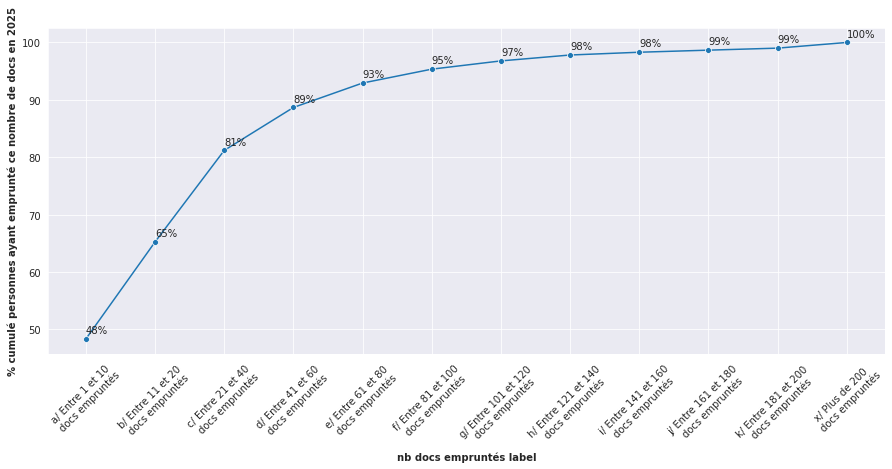

In [109]:
f,ax = plt.subplots(nrows=1,ncols=1)

ax = sns.lineplot(data=issues_dist_2,
             x=issues_dist_2.index,
             y='% cumulé personnes ayant emprunté ce nombre de docs en 2025',
             #ax=ax[1],
             marker='o',
           )

for x,y in zip(issues_dist_2.index,issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025']):
    plt.text(x=x,y=y+1,s = '{:.0f}'.format(y) + '%')

ax.tick_params(axis='x',rotation=45)